# Network Throughput Forecasting with LSTM

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

## 1. Data Preparation (Aggregation)
เนื่องจากข้อมูลดิบเป็นราย Packet เราต้องรวม (Aggregate) ให้เป็นรายวินาทีเพื่อสร้าง Time Series

In [ ]:
df = pd.read_csv('Midterm_53_group.csv')

df['Time_Sec'] = df['Time'].astype(int)

throughput_series = df.groupby('Time_Sec')['Length'].sum().reset_index()
throughput_series = throughput_series.rename(columns={'Length': 'Throughput'})

print(f"Total data points: {len(throughput_series)} seconds")
throughput_series.head()

Total data points: 1230 seconds


,Time_Sec,Throughput
0,0,184
1,1,60
2,2,60
3,3,60
4,8,60


## 2. Feature Scaling & Windowing
Neural Network ทำงานได้ดีที่สุดกับข้อมูลที่ถูก Scale ให้อยู่ในช่วง 0-1 และเราต้องทำ 'Windowing' เพื่อสร้าง Input ให้กับ LSTM

In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(throughput_series[['Throughput']].values)

def create_dataset(dataset, look_back=10):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

LOOK_BACK = 10
X, y = create_dataset(scaled_data, LOOK_BACK)

X = np.reshape(X, (X.shape[0], X.shape[1], 1))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"X_train shape: {X_train.shape}")

X_train shape: (976, 10, 1)


## 3. Build LSTM Model

In [4]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOK_BACK, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1) 
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

c:\Users\ananz\Network_intrusion_bot\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train Model

In [5]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train, 
    validation_data=(X_test, y_test), 
    epochs=50, 
    batch_size=32, 
    callbacks=[early_stop], 
    verbose=1
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0067 - val_loss: 0.0104
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0066 - val_loss: 0.0100
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0065 - val_loss: 0.0099
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0065 - val_loss: 0.0098
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0064 - val_loss: 0.0101
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0065 - val_loss: 0.0098
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0063 - val_loss: 0.0100
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0065 - val_loss: 0.0104
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0065 - val_loss: 0.0098


## 5. Evaluation & Visualization

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


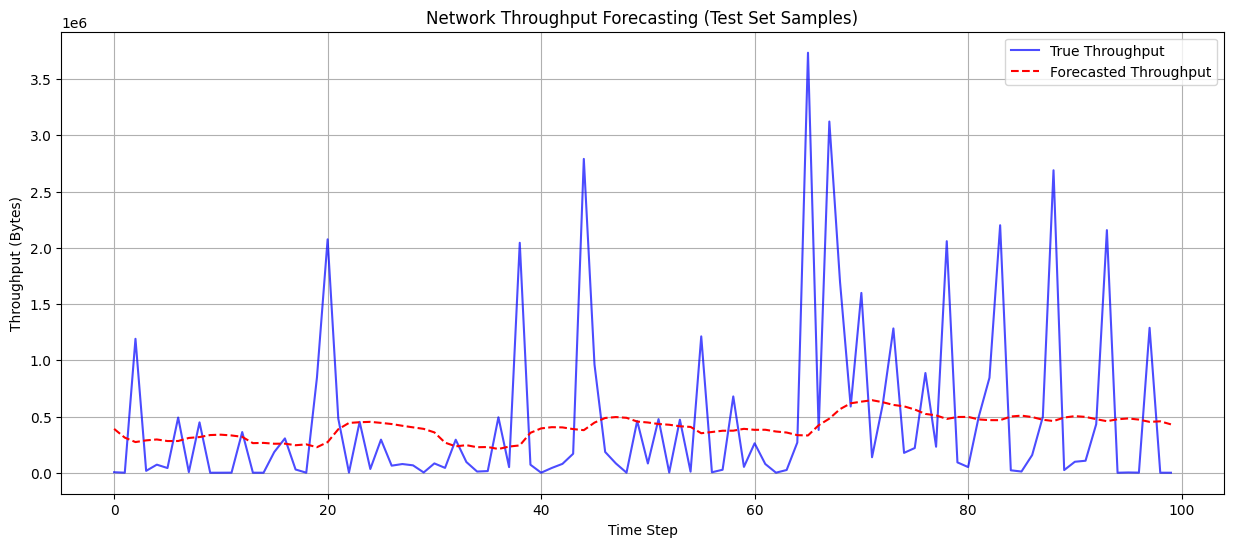

In [6]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

test_predict_inv = scaler.inverse_transform(test_predict)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

plt.figure(figsize=(15, 6))
plt.plot(y_test_inv[-100:], label='True Throughput', color='blue', alpha=0.7)
plt.plot(test_predict_inv[-100:], label='Forecasted Throughput', color='red', linestyle='--')
plt.title('Network Throughput Forecasting (Test Set Samples)')
plt.xlabel('Time Step')
plt.ylabel('Throughput (Bytes)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
THRESHOLD = throughput_series['Throughput'].mean() * 3
forecast = test_predict_inv[-1][0]

print(f"Next Second Forecast: {forecast:,.2f} Bytes")
if forecast > THRESHOLD:
    print("ALERT: Network congestion predicted in the next second!")
else:
    print("Prediction: Traffic is within normal range.")